# Lag analysis: how far climate leads dengue

With previous analysis same-month climate–case correlations are weak. The biology says climate should *lead* cases by one to two months. Here we correlate cases with each climate variable shifted back 0–4 months — **within each district's own series**, so no value leaks across districts or year boundaries.

All logic lives in `dengue_climate.analysis.crosscorr`; this notebook just runs and reads it.

In [2]:
from dengue_climate.analysis.crosscorr import (
    load_panel, lag_correlations, best_lags, best_lag_matrix, add_lagged_features,
)
from dengue_climate.config import get_path

panel = load_panel()
corr_table = lag_correlations(panel)
best = best_lags(corr_table)
len(panel), corr_table.shape

(2772, (100, 4))

## 1. Pooled correlation by lag

Each variable's Pearson r with cases at lags 0–4. The lag where r peaks is where that variable best anticipates an outbreak.

In [3]:
pooled = corr_table[corr_table['band'] == 'All'].pivot(
    index='variable', columns='lag', values='r')
pooled

lag,0,1,2,3,4
variable,,,,,
humidity,0.143,0.146,0.108,0.025,-0.073
precip,0.086,0.150,0.177,0.134,0.048
temp_max,0.044,0.069,0.092,0.114,0.125
temp_mean,0.073,0.100,0.115,0.124,0.119
temp_min,0.096,0.122,0.130,0.126,0.107


## 2. The headline figure

Saved to `outputs/figures/lag_correlation.png` by `crosscorr.main()`; the dominant lag of each variable is ringed.

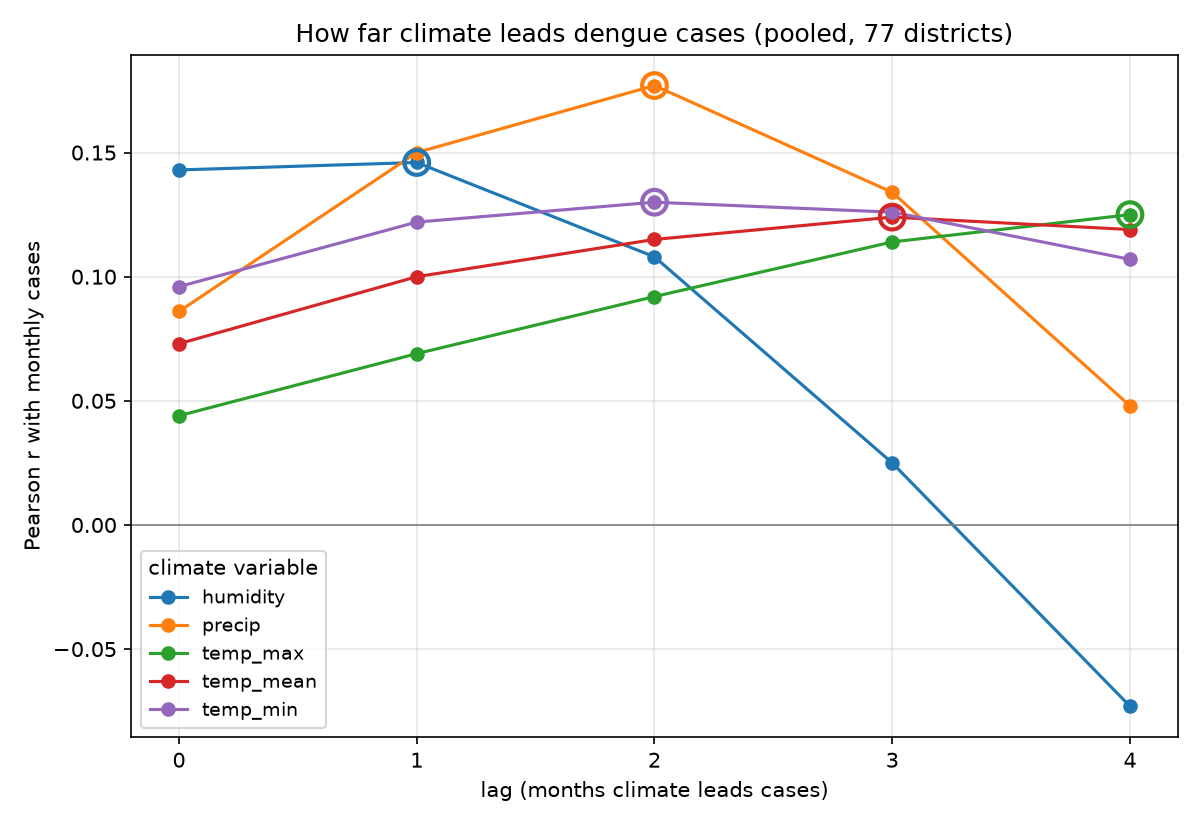

In [4]:
from dengue_climate.viz.plots import plot_lag_correlation
from IPython.display import Image

fig_path = plot_lag_correlation(corr_table, best, get_path('figures') / 'lag_correlation.png')
Image(str(fig_path))

## 3. Best lag per variable per band

Does the lead time shift along the elevation gradient (Terai → Hill → Mountain)?

In [5]:
best_lag_matrix(best)

band,All,Terai,Hill,Mountain
variable,,,,
precip,2,1,2,2
temp_mean,3,3,3,2
temp_max,4,3,4,4
temp_min,2,2,2,2
humidity,1,0,1,1


**Reading it:** rainfall leads cases by ~2 months, humidity by ~1, temperature by 2–3. Humidity acts a month sooner in the Terai than in the hills — consistent with cases being established earlier at low elevation and arriving later upslope.

## 4. Lagged predictors for the model

`add_lagged_features` materialises the shifted columns the negative-binomial model will use. The first months of each district are NaN (no prior reading) and get dropped before fitting.

In [6]:
lagged = add_lagged_features(panel, lags=(1, 2))
lagged[['district', 'year', 'month', 'cases', 'precip', 'precip_lag1', 'precip_lag2']].head(8)

,district,year,month,cases,precip,precip_lag1,precip_lag2
0,Achham,2022,1,0,37.25,NaN,NaN
1,Achham,2022,2,0,67.76,37.25,NaN
2,Achham,2022,3,0,0.50,67.76,37.25
3,Achham,2022,4,0,15.79,0.50,67.76
4,Achham,2022,5,1,97.35,15.79,0.50
5,Achham,2022,6,1,72.61,97.35,15.79
6,Achham,2022,7,1,196.80,72.61,97.35
7,Achham,2022,8,1,205.94,196.80,72.61
